Bank Marketing Classification

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report,PrecisionRecallDisplay,RocCurveDisplay
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from mixed_naive_bayes import MixedNB

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import CategoricalNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
import lightgbm as lgb


**Load dataset & inspect target distribution**

This dataset has 20 features, 1 target, and 2000 entries. The meanings of the features are given below.

#features:
<font size="2">
   - age (numeric)
   - job : type of job (categorical: "admin.","blue-collar","entrepreneur","housemaid","management",  "retired","self-employed","services","student","technician","unemployed","unknown")
   - marital : marital status (categorical: "divorced","married","single","unknown"; note: "divorced" means divorced or widowed)
   - education (categorical: "basic.4y","basic.6y","basic.9y","high.school","illiterate","professional.course","university.degree","unknown")
   - default: has credit in default? (categorical: "no","yes","unknown")
   - housing: has housing loan? (categorical: "no","yes","unknown")
   - loan: has personal loan? (categorical: "no","yes","unknown")
   - contact: contact communication type (categorical: "cellular","telephone") 
   - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
   - day_of_week: last contact day of the week (categorical: "mon","tue","wed","thu","fri")
   - duration: last contact duration, in seconds (numeric). Important note:  this attribute highly affects the output target (e.g., if duration=0 then y="no"). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
   - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
   - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
   - previous: number of contacts performed before this campaign and for this client (numeric)
   - poutcome: outcome of the previous marketing campaign (categorical: "failure","nonexistent","success")
   - emp.var.rate: employment variation rate - quarterly indicator (numeric)
   - cons.price.idx: consumer price index - monthly indicator (numeric)     
   - cons.conf.idx: consumer confidence index - monthly indicator (numeric)     
   - euribor3m: euribor 3 month rate - daily indicator (numeric)
   - nr.employed: number of employees - quarterly indicator (numeric)
   Output variable (desired target):
   -y - has the client subscribed a term deposit? (binary: "yes","no")
</font>


In [2]:
bank_marketing_df = pd.read_csv("./bank-marketing-dataset-full.csv", sep=';')

In [3]:
bank_marketing_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
bank_marketing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [4]:
# EDA for Target variable
print(bank_marketing_df.dtypes.value_counts())
print("\nTarget distribution:")
print(bank_marketing_df['y'].value_counts(normalize=True))
print("\nSample missing values per column:")
print(bank_marketing_df.isna().sum().sort_values(ascending=False).head())

# Convert target to 0/1
bank_marketing_df['target'] = (bank_marketing_df['y'] == 'yes').astype(int)
bank_marketing_df.drop(columns=['y'], inplace=True)

object     11
int64       5
float64     5
Name: count, dtype: int64

Target distribution:
y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

Sample missing values per column:
age          0
job          0
marital      0
education    0
default      0
dtype: int64


In [5]:
bank_marketing_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,target
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


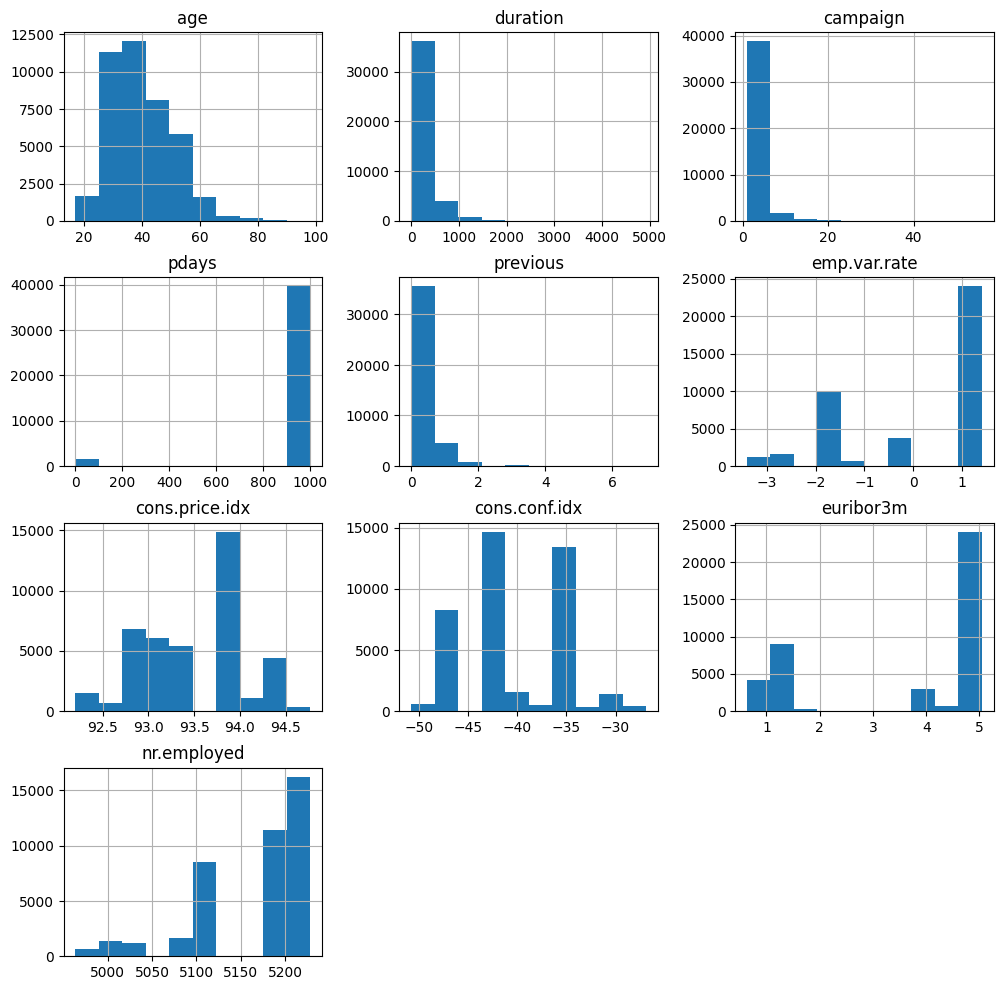

In [6]:
X = bank_marketing_df.drop("target", axis = 1)
y = bank_marketing_df['target'].values.flatten()

X.hist(figsize=(12,12));

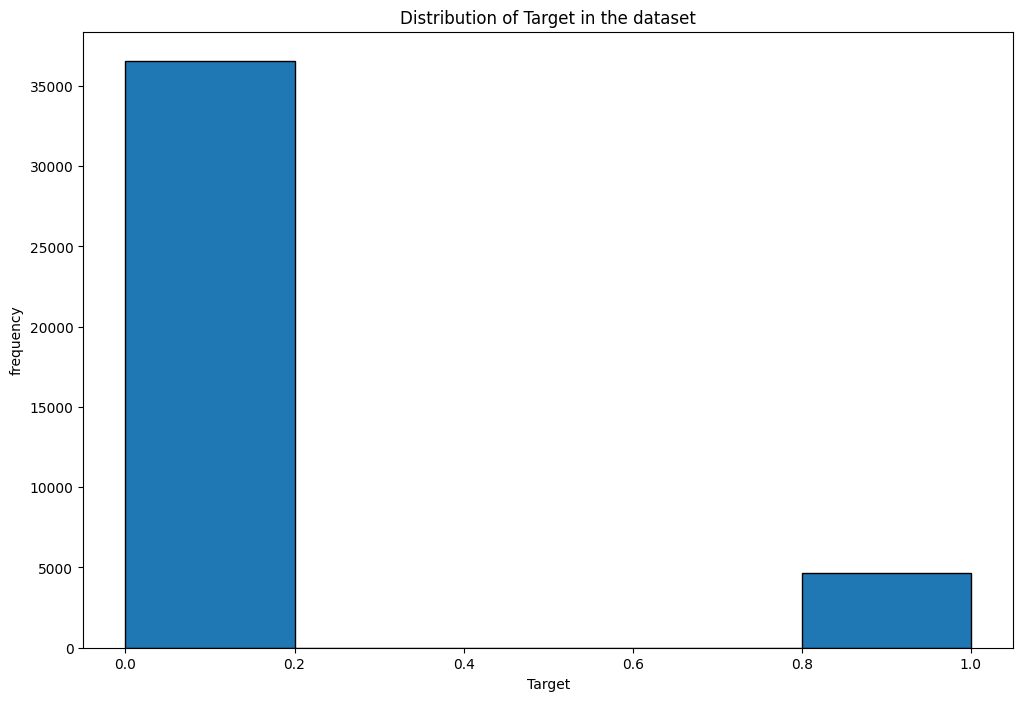

In [6]:
plt.figure(figsize=(12,8))
plt.hist(bank_marketing_df['target'], bins=5, edgecolor='k')
plt.title("Distribution of Target in the dataset")
plt.xlabel("Target")
plt.ylabel("frequency")
plt.show()

numerical ad Categorical Cols

In [7]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print("numerical_cols",numerical_cols)
print("categorical_cols",categorical_cols)

numerical_cols ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
categorical_cols ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


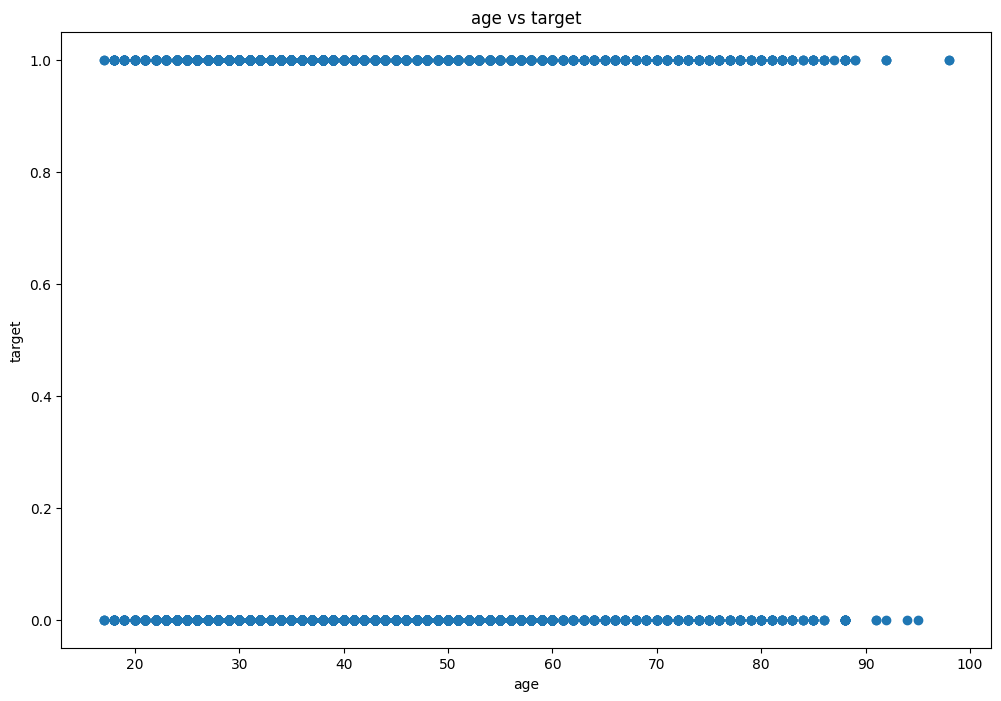

In [8]:
plt.figure(figsize=(12,8))
plt.scatter(bank_marketing_df['age'], bank_marketing_df['target'])
plt.xlabel('age')
plt.ylabel('target')
plt.title("age vs target")
plt.show()

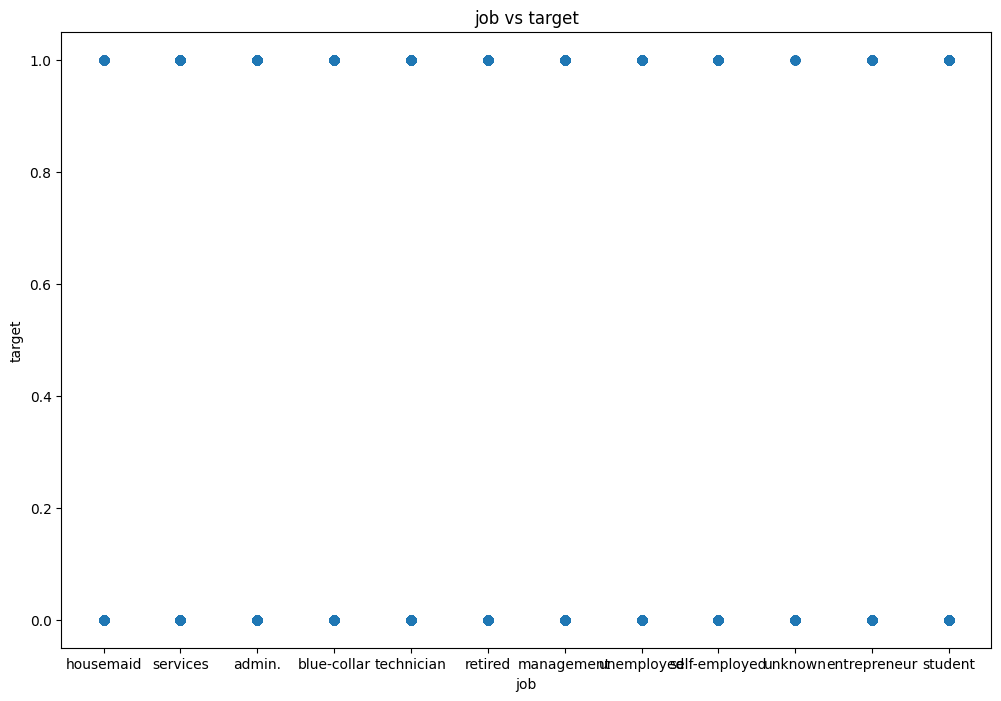

In [9]:
plt.figure(figsize=(12,8))
plt.scatter(bank_marketing_df['job'], bank_marketing_df['target'])
plt.xlabel('job')
plt.ylabel('target')
plt.title("job vs target")
plt.show()

In [9]:
bank_marketing_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,target
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


**Preprocessing & Baselines**

In [10]:
X_all = bank_marketing_df.drop("target", axis = 1)
y_all = bank_marketing_df['target'].values.flatten()

In [11]:
numerical_cols = X_all.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols =X_all.select_dtypes(include=['object', 'category']).columns.tolist()
print("numerical_cols",numerical_cols)
print("categorical_cols",categorical_cols)

numerical_cols ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
categorical_cols ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


Preprocessor

In [12]:
preprocessor = ColumnTransformer(
                    transformers=[
                        ("standard_scaler", StandardScaler(), numerical_cols),
                        ("one_hot_encoder", OneHotEncoder(), categorical_cols)
                    ]
                )


Train Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.25, random_state=123)

print(f'Train size: {X_train.shape}  |  Test size: {X_test.shape}')


Train size: (30891, 20)  |  Test size: (10297, 20)


 **Baseline Models**
 

In [14]:
def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te, results):
    cv_rmse =0
    cv_std =0
    pipeline.fit(X_tr, y_tr)
    y_pred_train = pipeline.predict(X_tr)
    y_pred_test = pipeline.predict(X_te)

    accuracy_score_tr = accuracy_score(y_tr, y_pred_train)
    accuracy_score_test = accuracy_score(y_te, y_pred_test)
    if name in ('Random Forest','XGBClassifier','LGBMClassifier'):
       cv_scores = cross_val_score(pipeline, X_tr, y_tr,
                                cv=5, scoring='neg_root_mean_squared_error')
       cv_rmse = -cv_scores.mean()
       cv_std = cv_scores.std()

    results.append({
        'Model': name,
        'Train Accuracy': accuracy_score_tr,
        'Test Accuracy': accuracy_score_test,
        'CV RMSE (mean±std)': f'{cv_rmse} ± {cv_std}'
    })

    report = classification_report(y_te, y_pred_test)
    
    
    #print(classification_report(y_test, y_pred))
    print(f'{'\033[1m'+name+'\033[0m':30s}\n  Train Accuracy={accuracy_score_tr}  Test Accuracy={accuracy_score_test}\n \nClassification Report\n {report}')
    print('ConfusionMatrix')
    cm = confusion_matrix(y_te, y_pred_test)
    ConfusionMatrixDisplay(cm).plot();
    plt.show()
    return pipeline

GaussianNB            
  Train Accuracy=0.812404907578259  Test Accuracy=0.8142177333203846
 
Classification Report
               precision    recall  f1-score   support

           0       0.95      0.83      0.89      9114
           1       0.34      0.68      0.46      1183

    accuracy                           0.81     10297
   macro avg       0.65      0.76      0.67     10297
weighted avg       0.88      0.81      0.84     10297

ConfusionMatrix


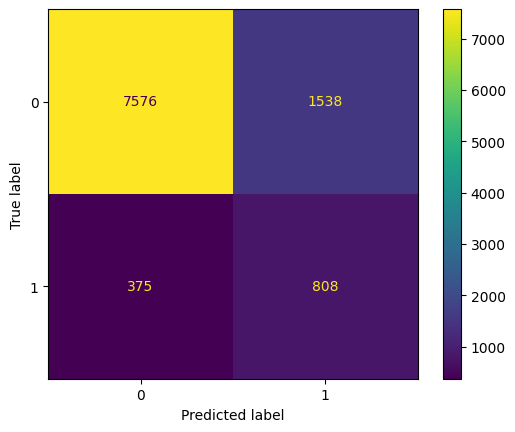


DecisionTreeClassifier
  Train Accuracy=0.9564921821889871  Test Accuracy=0.8994852869767893
 
Classification Report
               precision    recall  f1-score   support

           0       0.94      0.95      0.94      9114
           1       0.57      0.54      0.55      1183

    accuracy                           0.90     10297
   macro avg       0.75      0.74      0.75     10297
weighted avg       0.90      0.90      0.90     10297

ConfusionMatrix


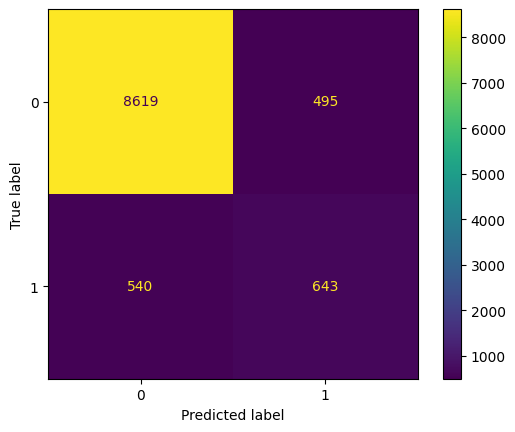


LogisticRegression    
  Train Accuracy=0.9113333980771099  Test Accuracy=0.9123045547246771
 
Classification Report
               precision    recall  f1-score   support

           0       0.93      0.97      0.95      9114
           1       0.69      0.43      0.53      1183

    accuracy                           0.91     10297
   macro avg       0.81      0.70      0.74     10297
weighted avg       0.90      0.91      0.90     10297

ConfusionMatrix


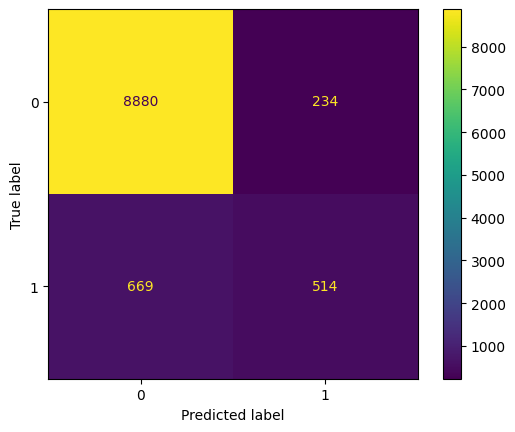

,Model,Train Accuracy,Test Accuracy,CV RMSE (mean±std)
0,GaussianNB,0.812405,0.814218,0 ± 0
1,DecisionTreeClassifier,0.956492,0.899485,0 ± 0
2,LogisticRegression,0.911333,0.912305,0 ± 0


In [15]:
results = []

baselines = {
    'GaussianNB': GaussianNB(),
    'DecisionTreeClassifier': DecisionTreeClassifier(min_samples_leaf=5),
    'LogisticRegression': LogisticRegression()
}

fitted_pipelines = {}
for name, model in baselines.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    fitted_pipelines[name] = evaluate_model(name, pipe, X_train, y_train, X_test, y_test, results)
    print()
pd.DataFrame(results)


**Advanced Models & Imbalance Handling**

Random Forest         
  Train Accuracy=0.9568806448480139  Test Accuracy=0.9023016412547344
 
Classification Report
               precision    recall  f1-score   support

           0       0.97      0.92      0.94      9114
           1       0.55      0.77      0.64      1183

    accuracy                           0.90     10297
   macro avg       0.76      0.84      0.79     10297
weighted avg       0.92      0.90      0.91     10297

ConfusionMatrix


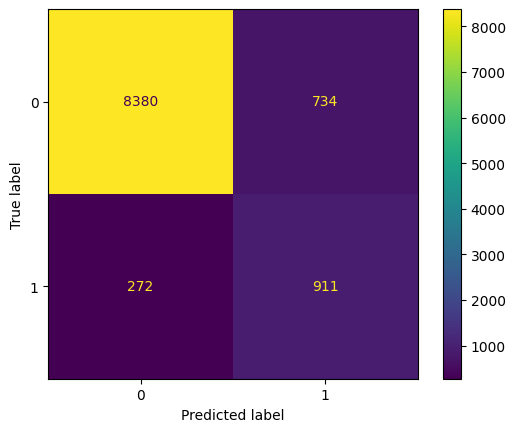


XGBClassifier         
  Train Accuracy=0.9291703085040951  Test Accuracy=0.9166747596387297
 
Classification Report
               precision    recall  f1-score   support

           0       0.94      0.96      0.95      9114
           1       0.66      0.56      0.61      1183

    accuracy                           0.92     10297
   macro avg       0.80      0.76      0.78     10297
weighted avg       0.91      0.92      0.91     10297

ConfusionMatrix


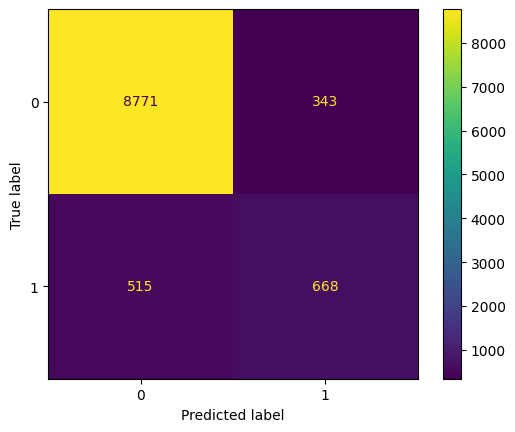


[LightGBM] [Info] Number of positive: 3457, number of negative: 27434
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003835 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 694
[LightGBM] [Info] Number of data points in the train set: 30891, number of used features: 61
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 2765, number of negative: 21947
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 690
[LightGBM] [Info] Number of data points in the train set: 24712, number of used features: 61
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 2766, number of negative: 21947
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003220 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 692
[LightGBM] [Info] Number of data points in the train set: 24713, number of used features: 61
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


...

[LightGBM] [Info] Number of positive: 2766, number of negative: 21947
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001818 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 693
[LightGBM] [Info] Number of data points in the train set: 24713, number of used features: 61
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 2765, number of negative: 21948
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002301 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 692
[LightGBM] [Info] Number of data points in the train set: 24713, number of used features: 61
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGBMClassifier        
  Train Accuracy=0.9148943057848564  Test Accuracy=0.8844323589394969
 
Classification Report
               precision    recall  f1-score   support

           0       0.98      0.88      0.93      9114
           1       0.50      0.89      0.64      1183

    accuracy                           0.88     10297
   macro avg       0.74      0.89      0.79     10297
weighted avg       0.93      0.88      0.90     10297

ConfusionMatrix


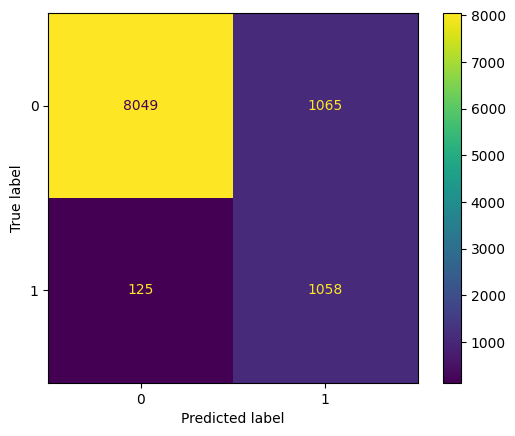

,Model,Train Accuracy,Test Accuracy,CV RMSE (mean±std)
0,Random Forest,0.956881,0.902302,0.306488919255408 ± 0.006315953255004511
1,XGBClassifier,0.929170,0.916675,0.28797894039145866 ± 0.0022087556284386568
2,LGBMClassifier,0.914894,0.884432,0.33632612735590384 ± 0.004929235523176838


In [16]:
results = []

baselines = {
    'Random Forest': RandomForestClassifier(n_estimators=200, min_samples_split=10,class_weight='balanced'),
    'XGBClassifier': XGBClassifier(eval_metric='auc', n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42),
    'LGBMClassifier':lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=42,class_weight='balanced')
}

fitted_pipelines = {}
for name, model in baselines.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    fitted_pipelines[name] = evaluate_model(name, pipe, X_train, y_train, X_test, y_test, results)
    print()
pd.DataFrame(results)

Hyperparameter tuning-Optuna

In [17]:
ordinal_transformer = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='median'), numerical_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
])

In [18]:
X_hyp =ordinal_transformer.fit_transform(X_train)
X_test_hyp = ordinal_transformer.fit_transform(X_test)
print(X_test_hyp.shape ,X_test_hyp.shape)

(10297, 20) (10297, 20)


In [19]:
# Optuna for XGBClassifier
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score

def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-3, 10.0),
        'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-3, 10.0)
    }
    clf = XGBClassifier(use_label_encoder=False, eval_metric='auc', random_state=42, **param)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(clf, X_hyp, y_train, scoring='roc_auc', cv=skf, n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)
print("Best optuna params:", study.best_params)
# Train final with best params
optuna_xgb = XGBClassifier(use_label_encoder=False, eval_metric='auc', random_state=42, **study.best_params)
optuna_xgb.fit(X_hyp, y_train)
print("Optuna XGBClassifier Test AUC:", roc_auc_score(y_test, optuna_xgb.predict_proba(X_test_hyp)[:,1]))
XGB_AUC = roc_auc_score(y_test, optuna_xgb.predict_proba(X_test_hyp)[:,1])
                    

c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-30 12:17:32,995] A new study created in memory with name: no-name-c9cc047b-bab7-483f-8374-b0e811dccd0c
  0%|          | 0/30 [00:00<?, ?it/s]C:\Users\HP\AppData\Local\Temp\ipykernel_6664\307502309.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),
C:\Users\HP\AppData\Local\Temp\ipykernel_6664\307502309.py:11: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0

[I 2026-04-30 12:17:51,079] Trial 0 finished with value: 0.9487564993491263 and parameters: {'n_estimators': 402, 'learning_rate': 0.014476050070316392, 'max_depth': 8, 'subsample': 0.714018880814387, 'colsample_bytree': 0.8903636602210823, 'reg_alpha': 0.009991846310070931, 'reg_lambda': 0.8105668386648859}. Best is trial 0 with value: 0.9487564993491263.


Best trial: 0. Best value: 0.948756:   7%|▋         | 2/30 [00:24<05:08, 11.01s/it]C:\Users\HP\AppData\Local\Temp\ipykernel_6664\307502309.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),
C:\Users\HP\AppData\Local\Temp\ipykernel_6664\307502309.py:11: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
C:\Users\HP\AppData\Local\Temp\ipykernel_6664\307502309.py:12: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'colsample_byt

[I 2026-04-30 12:17:57,128] Trial 1 finished with value: 0.9469025521076304 and parameters: {'n_estimators': 124, 'learning_rate': 0.04410478726004451, 'max_depth': 5, 'subsample': 0.8539391183717533, 'colsample_bytree': 0.8205441587158344, 'reg_alpha': 6.70282142688679, 'reg_lambda': 0.018833166501869694}. Best is trial 0 with value: 0.9487564993491263.


Best trial: 0. Best value: 0.948756:  10%|█         | 3/30 [00:25<02:54,  6.47s/it]C:\Users\HP\AppData\Local\Temp\ipykernel_6664\307502309.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),
C:\Users\HP\AppData\Local\Temp\ipykernel_6664\307502309.py:11: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
C:\Users\HP\AppData\Local\Temp\ipykernel_6664\307502309.py:12: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'colsample_byt

...

[I 2026-04-30 12:19:20,838] Trial 28 finished with value: 0.9487205580652159 and parameters: {'n_estimators': 318, 'learning_rate': 0.03820758541664004, 'max_depth': 7, 'subsample': 0.993402919513051, 'colsample_bytree': 0.642982604468902, 'reg_alpha': 3.2452698632824077, 'reg_lambda': 0.1066034107660496}. Best is trial 27 with value: 0.9491942788314366.


Best trial: 27. Best value: 0.949194: 100%|██████████| 30/30 [01:52<00:00,  3.75s/it]


[I 2026-04-30 12:19:25,353] Trial 29 finished with value: 0.9490166392193388 and parameters: {'n_estimators': 409, 'learning_rate': 0.01517276680204372, 'max_depth': 8, 'subsample': 0.9339382189507667, 'colsample_bytree': 0.6970037507403629, 'reg_alpha': 4.937447231719757, 'reg_lambda': 0.04182513542555464}. Best is trial 27 with value: 0.9491942788314366.
Best optuna params: {'n_estimators': 341, 'learning_rate': 0.023434146621363592, 'max_depth': 7, 'subsample': 0.9295450694986673, 'colsample_bytree': 0.6346113776457935, 'reg_alpha': 4.615344636953791, 'reg_lambda': 0.07690270654122512}


c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:19:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Optuna XGBClassifier Test AUC: 0.9518788127690745


In [20]:
# Optuna for Random Forest Classifier
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score

def objective(trial):
    param = {
        'n_estimators': trial.suggest_int("n_estimators", 10, 200, log=True),
        'max_depth': trial.suggest_int("max_depth", 2, 32),
        'min_samples_split': trial.suggest_int("min_samples_split", 2, 10),
        'min_samples_leaf': trial.suggest_int("min_samples_leaf", 1, 10)
    }
    clf = RandomForestClassifier(random_state=42, **param)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(clf, X_hyp, y_train, scoring='roc_auc', cv=skf, n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)
print("Best optuna params:", study.best_params)
# Train final with best params
optuna_rf = RandomForestClassifier( random_state=42, **study.best_params)
optuna_rf.fit(X_hyp, y_train)
print("Optuna RandomForestClassifier Test AUC:", roc_auc_score(y_test, optuna_rf.predict_proba(X_test_hyp)[:,1]))
RFC_AUC = roc_auc_score(y_test, optuna_rf.predict_proba(X_test_hyp)[:,1])

[I 2026-04-30 12:19:35,343] A new study created in memory with name: no-name-ef35e184-b02f-482d-a46e-4e410086781c
  0%|          | 0/30 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.946349:   3%|▎         | 1/30 [00:08<04:13,  8.75s/it]

[I 2026-04-30 12:19:44,075] Trial 0 finished with value: 0.9463492911387824 and parameters: {'n_estimators': 135, 'max_depth': 26, 'min_samples_split': 2, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.9463492911387824.


Best trial: 0. Best value: 0.946349:   7%|▋         | 2/30 [00:11<02:17,  4.93s/it]

[I 2026-04-30 12:19:46,329] Trial 1 finished with value: 0.9410800235781256 and parameters: {'n_estimators': 29, 'max_depth': 27, 'min_samples_split': 6, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.9463492911387824.


...

[I 2026-04-30 12:22:37,834] Trial 27 finished with value: 0.9466731199947446 and parameters: {'n_estimators': 158, 'max_depth': 29, 'min_samples_split': 8, 'min_samples_leaf': 6}. Best is trial 12 with value: 0.9470463324326551.


Best trial: 12. Best value: 0.947046:  97%|█████████▋| 29/30 [03:03<00:07,  7.16s/it]

[I 2026-04-30 12:22:39,260] Trial 28 finished with value: 0.9408757131959152 and parameters: {'n_estimators': 15, 'max_depth': 30, 'min_samples_split': 10, 'min_samples_leaf': 2}. Best is trial 12 with value: 0.9470463324326551.


Best trial: 12. Best value: 0.947046: 100%|██████████| 30/30 [03:15<00:00,  6.51s/it]


[I 2026-04-30 12:22:50,447] Trial 29 finished with value: 0.9463863862603962 and parameters: {'n_estimators': 133, 'max_depth': 26, 'min_samples_split': 5, 'min_samples_leaf': 3}. Best is trial 12 with value: 0.9470463324326551.
Best optuna params: {'n_estimators': 186, 'max_depth': 32, 'min_samples_split': 10, 'min_samples_leaf': 5}
Optuna RandomForestClassifier Test AUC: 0.9494536286960453


In [21]:
# Optuna for LGBClassifier
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score

def objective(trial):
    param = {
        'objective': 'binary',
        'metric': 'auc',
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 500),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    clf = lgb.LGBMClassifier(**param)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(clf, X_hyp, y_train, scoring='roc_auc', cv=skf, n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)
print("Best optuna params:", study.best_params)
# Train final with best params
optuna_lgb = lgb.LGBMClassifier(use_label_encoder=False, eval_metric='auc', random_state=42, **study.best_params)
optuna_lgb.fit(X_hyp, y_train)
print("Optuna LGBMClassifier Test AUC:", roc_auc_score(y_test, optuna_lgb.predict_proba(X_test_hyp)[:,1]))
LGB_AUC = roc_auc_score(y_test, optuna_lgb.predict_proba(X_test_hyp)[:,1])

[I 2026-04-30 12:23:09,396] A new study created in memory with name: no-name-75c01c13-210b-47e2-a688-8935a172545b
Best trial: 0. Best value: 0.938229:   3%|▎         | 1/30 [00:26<12:40, 26.22s/it]

[I 2026-04-30 12:23:35,609] Trial 0 finished with value: 0.9382289768388311 and parameters: {'n_estimators': 741, 'learning_rate': 0.15814978203167693, 'num_leaves': 294, 'max_depth': 15, 'min_child_samples': 256, 'subsample': 0.8154150232280615, 'colsample_bytree': 0.611158439604677}. Best is trial 0 with value: 0.9382289768388311.


Best trial: 1. Best value: 0.941321:   7%|▋         | 2/30 [01:06<16:01, 34.34s/it]

[I 2026-04-30 12:24:15,640] Trial 1 finished with value: 0.9413208462339858 and parameters: {'n_estimators': 906, 'learning_rate': 0.055153421465200206, 'num_leaves': 297, 'max_depth': 12, 'min_child_samples': 52, 'subsample': 0.8617553894360225, 'colsample_bytree': 0.921001113793404}. Best is trial 1 with value: 0.9413208462339858.


Best trial: 2. Best value: 0.945241:  10%|█         | 3/30 [01:08<08:53, 19.76s/it]

...

Best trial: 12. Best value: 0.949105: 100%|██████████| 30/30 [06:32<00:00, 13.09s/it]


[I 2026-04-30 12:29:41,981] Trial 29 finished with value: 0.9457309024887158 and parameters: {'n_estimators': 583, 'learning_rate': 0.03864280008343794, 'num_leaves': 54, 'max_depth': 15, 'min_child_samples': 243, 'subsample': 0.7670461249243071, 'colsample_bytree': 0.8424275638855679}. Best is trial 12 with value: 0.9491053152113403.
Best optuna params: {'n_estimators': 609, 'learning_rate': 0.010223594686523757, 'num_leaves': 58, 'max_depth': 10, 'min_child_samples': 118, 'subsample': 0.6252542151658301, 'colsample_bytree': 0.6748552503373839}
[LightGBM] [Warning] Unknown parameter: use_label_encoder
[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Warning] Unknown parameter: use_label_encoder
[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Info] Number of positive: 3457, number of negative: 27434
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007144 seconds.
You can set `force_row_wise=true` to remove the overhe

c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] Unknown parameter: use_label_encoder
[LightGBM] [Warning] Unknown parameter: eval_metric
Optuna LGBMClassifier Test AUC: 0.9523108346220719
[LightGBM] [Warning] Unknown parameter: use_label_encoder
[LightGBM] [Warning] Unknown parameter: eval_metric


c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [27]:
auc_score = [{'XGB Classifier': XGB_AUC,'Random Forest Classifier' :RFC_AUC, 'LGB Classifier' :LGB_AUC }]
print(auc_score)

[{'XGB Classifier': 0.9518788127690745, 'Random Forest Classifier': 0.9494536286960453, 'LGB Classifier': 0.9523108346220719}]


In [29]:
print('AUC Score')
pd.DataFrame(auc_score)

AUC Score


,XGB Classifier,Random Forest Classifier,LGB Classifier
0,0.951879,0.949454,0.952311


**ROC & Precision-Recall curves**

[LightGBM] [Info] Number of positive: 3457, number of negative: 27434
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002969 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 726
[LightGBM] [Info] Number of data points in the train set: 30891, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.111910 -> initscore=-2.071382
[LightGBM] [Info] Start training from score -2.071382
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warning

[LightGBM] [Info] Number of positive: 3457, number of negative: 27434
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001962 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 726
[LightGBM] [Info] Number of data points in the train set: 30891, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.111910 -> initscore=-2.071382
[LightGBM] [Info] Start training from score -2.071382
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


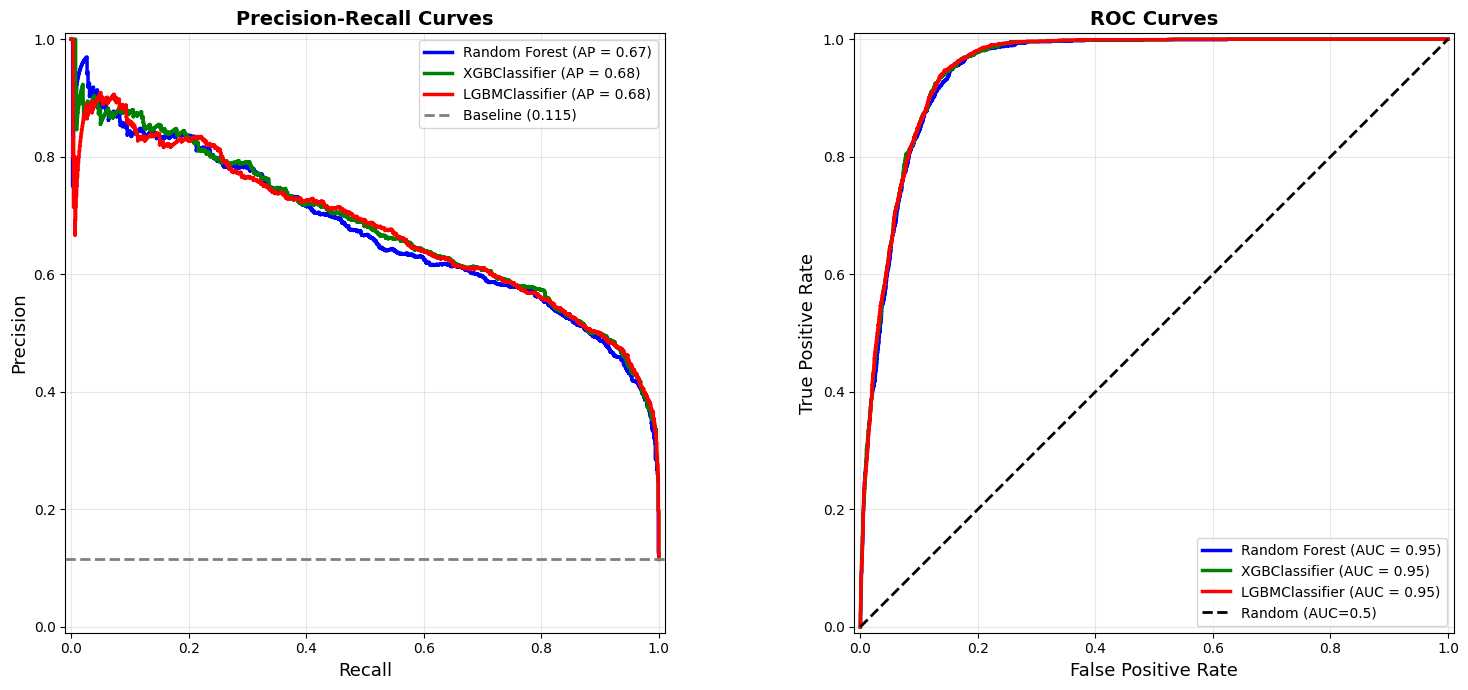

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# PR Curves
ax = axes[0]
colors = ['blue', 'green', 'red']
models = {
    'Random Forest': RandomForestClassifier(n_estimators= 186, max_depth= 32, min_samples_split= 10, min_samples_leaf=5),
    'XGBClassifier': XGBClassifier(n_estimators= 341, learning_rate= 0.023434146621363592, max_depth= 7, subsample= 0.9295450694986673, colsample_bytree= 0.6346113776457935, reg_alpha= 4.615344636953791, reg_lambda= 0.07690270654122512),
    'LGBMClassifier':lgb.LGBMClassifier(n_estimators= 609, learning_rate= 0.010223594686523757, num_leaves=58, max_depth =10, min_child_samples= 118,subsample= 0.6252542151658301, colsample_bytree= 0.6748552503373839)
}        
for (name, model), color in zip(models.items(), colors):
    model.fit(X_hyp, y_train)
    y_pred = model.predict_proba(X_test_hyp)[:, 1]
    display = PrecisionRecallDisplay.from_estimator(
        model, X_test_hyp, y_test, 
        name=name,
        ax=ax,
        color=color,
        linewidth=2.5
    )

chance_level = (y_test == 1).sum() / len(y_test)
ax.axhline(y=chance_level, color='gray', linestyle='--', 
          linewidth=2, label=f'Baseline ({chance_level:.3f})')
ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# ROC Curves
ax = axes[1]
for (name, model), color in zip(models.items(), colors):
    model.fit(X_hyp, y_train)
    y_pred = model.predict_proba(X_test_hyp)[:, 1]
    display = RocCurveDisplay.from_estimator(
        model, X_test_hyp, y_test,
        name=name,
        ax=ax,
        color=color,
        linewidth=2.5
    )

ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()